## Team
Aden Thompson

Cody Reep

10/09/2026

## Description

In this project, our team loaded the Titanic dataset with 891 entries and 12 features per entry. The target feature was the binary ‘Survived’ feature, where 1 indicated the passenger survived and 0 indicated they did not. Other features included the passenger’s class (Pclass), sibling and spouse count (SibSp), and their cabin number (Cabin).

Several features were dropped. Name and Ticket were dropped due to the inherent challenge of converting them into numeric values. Cabin was dropped because 687 of the 891 entries were null. Lastly, PassengerId was dropped as it lacked meaningful data.

Several of the remaining features required preprocessing, including imputation, scaling, and numeric encoding. Entries missing Age, an integer, and Embarked, a string, were assigned the median Age and most frequent Embarked status, respectively, of the non-null entries. Furthermore, Embarked and Sex were converted into numeric values using OneHotEncoder. To finish preprocessing, both Fare and Age had to be scaled using StandardScaler given their large ranges.

After preprocessing, we used sklearn’s random forest classifier to predict the target feature (i.e., survived). On the 712-entry training set, cross-validation (10) testing yielded a 75.10% and 71.79% precision score and recall score, respectively. On the 179-entry testing set, the model achieved a 74.07% and 57.97% precision score and recall score, respectively. In addition, for both the training and testing sets, confusion matrices were computed and ROC curves were plotted.


In [33]:
# Import libraries that are needed to train and test the model
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

In [34]:
# Import the dataset
# Get the data from the CSV file using pandas CSV functionality
data_path = "titanic.csv"
def load_titanic_data():
    csv_path = data_path
    return pd.read_csv(csv_path, sep=',', low_memory=False)

In [35]:
# Set the titanic variable equal to the pd dataframe provided by the function
titanic = load_titanic_data()

## Inspect Data

In [36]:
# View the info of the df for the first time
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [37]:
# View the description of the dataframe
titanic.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [38]:
# View the first five observations
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
# View the last five observations
titanic.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [40]:
# Get the shape of the df
titanic.shape

(891, 12)

In [41]:
# Drop the features Name and Ticket as they cannot be converted easily into a numeric value. Cabin will be dropped as it has too many null observations. Drop PassengerID as it has no useful data.
titanic = titanic.drop(["Name", "Ticket", "Cabin", "PassengerId"], axis=1)

In [42]:
# View the info of the df after dropping the 4 features
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [43]:
# Find numeric features with missing values
titanic.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

## Visualize the Data

array([[<Axes: xlabel='Survived', ylabel='Survived'>,
        <Axes: xlabel='Pclass', ylabel='Survived'>,
        <Axes: xlabel='Age', ylabel='Survived'>,
        <Axes: xlabel='SibSp', ylabel='Survived'>,
        <Axes: xlabel='Parch', ylabel='Survived'>,
        <Axes: xlabel='Fare', ylabel='Survived'>],
       [<Axes: xlabel='Survived', ylabel='Pclass'>,
        <Axes: xlabel='Pclass', ylabel='Pclass'>,
        <Axes: xlabel='Age', ylabel='Pclass'>,
        <Axes: xlabel='SibSp', ylabel='Pclass'>,
        <Axes: xlabel='Parch', ylabel='Pclass'>,
        <Axes: xlabel='Fare', ylabel='Pclass'>],
       [<Axes: xlabel='Survived', ylabel='Age'>,
        <Axes: xlabel='Pclass', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='SibSp', ylabel='Age'>,
        <Axes: xlabel='Parch', ylabel='Age'>,
        <Axes: xlabel='Fare', ylabel='Age'>],
       [<Axes: xlabel='Survived', ylabel='SibSp'>,
        <Axes: xlabel='Pclass', ylabel='SibSp'>,
        <Axes: xla

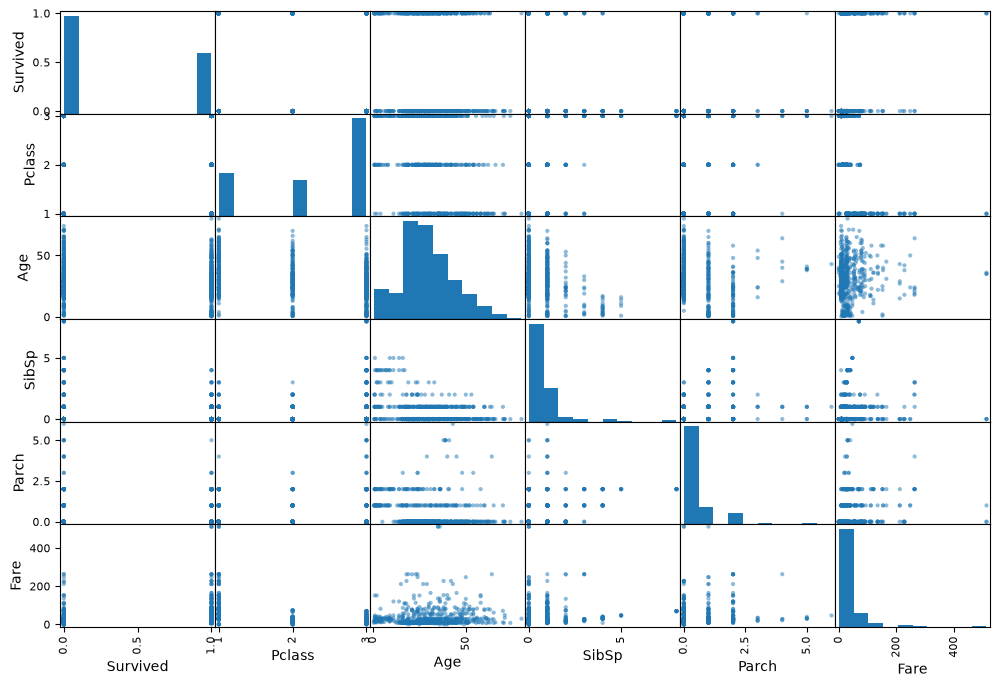

In [44]:
# Create a scatter plot matrix of all features with numeric data
scatter_matrix(titanic[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Embarked"]], figsize=(12, 8))

## Split the data into test and train sets

In [45]:
# Split the dataset using a stratified split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(titanic, titanic["Survived"]):
    strat_train_set = titanic.loc[train_index]
    strat_test_set = titanic.loc[test_index]

In [46]:
# View the info of the train set
strat_train_set.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    str    
 3   Age       575 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  710 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 50.1 KB


In [47]:
# View the info of the test set
strat_test_set.info()

<class 'pandas.DataFrame'>
Index: 179 entries, 565 to 637
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  179 non-null    int64  
 1   Pclass    179 non-null    int64  
 2   Sex       179 non-null    str    
 3   Age       139 non-null    float64
 4   SibSp     179 non-null    int64  
 5   Parch     179 non-null    int64  
 6   Fare      179 non-null    float64
 7   Embarked  179 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 12.6 KB


## Preprocess the Data

In [48]:
# Fill in the missing age values with the median age for the train set
imputer = SimpleImputer(strategy="median")
imputer.fit(strat_train_set[["Age"]])
strat_train_set[["Age"]] = imputer.transform(strat_train_set[["Age"]])

# Fill in the missing age values with the median age for the test set
imputer = SimpleImputer(strategy="median")
imputer.fit(strat_test_set[["Age"]])
strat_test_set[["Age"]] = imputer.transform(strat_test_set[["Age"]])

In [49]:
# Fill in the missing embarked values with the most frequent value for the train set
imputer = SimpleImputer(strategy="most_frequent")
imputer.fit(strat_train_set[["Embarked"]])
strat_train_set[["Embarked"]] = imputer.transform(strat_train_set[["Embarked"]])

# Fill in the missing embarked values with the most frequent value for the test set
imputer = SimpleImputer(strategy="most_frequent")
imputer.fit(strat_test_set[["Embarked"]])
strat_test_set[["Embarked"]] = imputer.transform(strat_test_set[["Embarked"]])

## Feature scaling and encoding

In [50]:
# Data encoding
# Use the OneHotEncoder to convert strings into numerical data
cat_encoder = OneHotEncoder()

# Encode the string data into numerical data for the train set
train_embarked_col = cat_encoder.fit_transform(strat_train_set[["Embarked"]])
train_sex_col = cat_encoder.fit_transform(strat_train_set[["Sex"]])

# Apply toarray method to the sparse array to convert it to a dense array
strat_train_set["Embarked"] = train_embarked_col.toarray()
strat_train_set["Sex"] = train_sex_col.toarray()

# Use the OneHotEncoder to convert strings into numerical data
cat_encoder = OneHotEncoder()

# Encode the string data into numerical data for the test set
test_embarked_col = cat_encoder.fit_transform(strat_test_set[["Embarked"]])
test_sex_col = cat_encoder.fit_transform(strat_test_set[["Sex"]])

# Apply toarray method to the sparse array to convert it to a dense array
strat_test_set["Embarked"]= test_embarked_col.toarray()
strat_test_set["Sex"]= test_sex_col.toarray()

In [51]:
# Data scaling
# Scale the data for the train set
scaler = StandardScaler()
scaler.fit(strat_train_set[["Fare"]])
strat_train_set[["Fare"]] = scaler.transform(strat_train_set[["Fare"]])
scaler.fit(strat_train_set[["Age"]])
strat_train_set[["Age"]] = scaler.transform(strat_train_set[["Age"]])

# Scale the data for the test set
scaler = StandardScaler()
scaler.fit(strat_test_set[["Fare"]])
strat_test_set[["Fare"]] = scaler.transform(strat_test_set[["Fare"]])
scaler.fit(strat_test_set[["Age"]])
strat_test_set[["Age"]] = scaler.transform(strat_test_set[["Age"]])

# Train the model

In [52]:
# Get the features (columns used in prediction) and the target (what you are trying to predict) from the train set
X_train = strat_train_set.drop("Survived", axis=1) # Drop Survived column for features
Y_train = strat_train_set["Survived"].copy() # Copy Survived column for target

In [53]:
# Use a random forest classifier for the model
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
# Fit the training dataset to the model to predict the feature "Survived"
forest_clf.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Simple Evaluation of the Model

In [54]:
# Get the predictions of the model on the train set.
Y_pred = forest_clf.predict(X_train)

In [55]:
# View the Precision, Recall, and Confusion matrix of the model on the train set

# Precision
print(precision_score(Y_train, Y_pred))
# Recall
print(recall_score(Y_train, Y_pred))
# Confusion matrix
confusion_matrix(Y_train, Y_pred)

0.9961977186311787
0.9597069597069597


array([[438,   1],
       [ 11, 262]])

In [56]:
# Function to plot the ROC curve (from the Ch. 3 GitHub notebook)
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16)
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.grid(True)

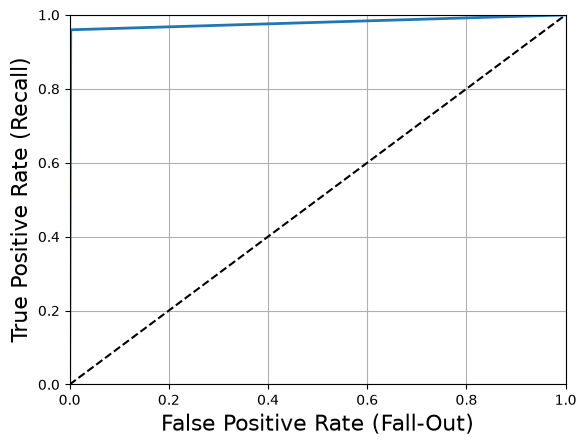

In [57]:
# Plot the ROC curve for the model on the train set
fpr, tpr, thresholds = roc_curve(Y_train, Y_pred)
plot_roc_curve(fpr, tpr)
plt.show()

## Improved Evaluation of the Model

In [58]:
# Get cross-validation scores for evaluation
y_scores = cross_val_predict(forest_clf, X_train, Y_train, cv=10)

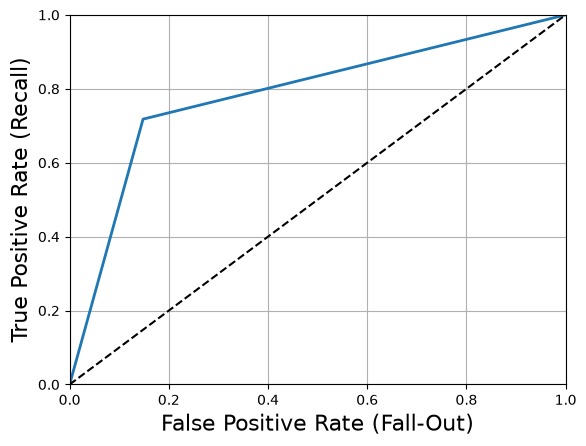

In [59]:
# Plot the ROC curve of the cross-validation
fpr2, tpr2, thresholds = roc_curve(Y_train, y_scores)
plot_roc_curve(fpr2, tpr2)
plt.show()

In [60]:
# View the Precision, Recall, and Confusion matrix of the model on the train set using cross-validation

# Precision
print(precision_score(Y_train, y_scores))
# Recall
print(recall_score(Y_train, y_scores))
# Confusion matrix
confusion_matrix(Y_train, y_scores)

0.7509578544061303
0.717948717948718


array([[374,  65],
       [ 77, 196]])

## Evaluate the Model on the Test Set

In [61]:
# Get the features (columns used in prediction) and the target (what you are trying to predict) from the test set
X_test = strat_test_set.drop("Survived", axis=1) # Drop Survived column for features
Y_test = strat_test_set["Survived"].copy() # Copy Survived column for target

In [62]:
# Get final prediction values to evaluate the model on a test set
final_predictions = forest_clf.predict(X_test)

In [63]:
# View the Precision, Recall, and Confusion matrix of the model on the test set

# Precision
print(precision_score(Y_test, final_predictions))
# Recall
print(recall_score(Y_test, final_predictions))
# Confusion matrix
confusion_matrix(Y_test, final_predictions)

0.7407407407407407
0.5797101449275363


array([[96, 14],
       [29, 40]])

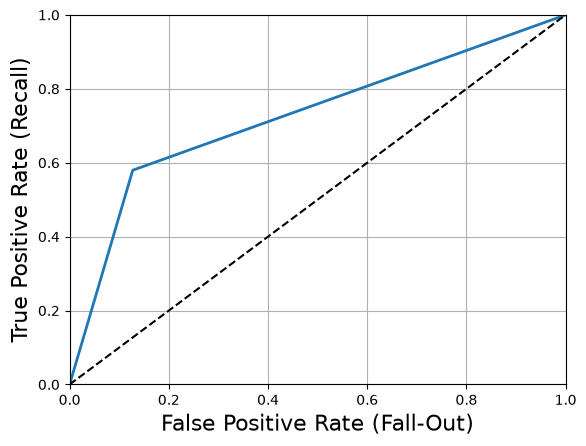

In [64]:
# Plot the ROC curve of the model on the test set
fpr3, tpr3, thresholds = roc_curve(Y_test, final_predictions)
plot_roc_curve(fpr3, tpr3)